In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from collections import defaultdict

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")

# ========================================
# Method 1: Individual plots for each sheet
# ========================================

def plot_elo_progression_individual(file_paths):
    """Create separate line plots for each Excel sheet"""
    
    for i, file_path in enumerate(file_paths):
        # Load the data
        df = pd.read_excel(file_path)
        
        # Create the plot
        plt.figure(figsize=(12, 8))
        
        # Get unique subjects
        unique_subjects = df['subject_id'].unique()
        
        # Plot each subject's ELO progression
        for subject in unique_subjects:
            subject_data = df[df['subject_id'] == subject].reset_index(drop=True)
            
            # Use row index as time (since rows are in temporal order)
            time_points = range(len(subject_data))
            elo_scores = subject_data['updated_elo_rating']
            
            plt.plot(time_points, elo_scores, marker='o', linewidth=2, 
                    markersize=4, label=f'{subject}', alpha=0.8)
        
        # Customize the plot
        plt.title(f'ELO Progression Over Time - {os.path.basename(file_path)}', 
                 fontsize=16, fontweight='bold')
        plt.xlabel('Match Number (Temporal Order)', fontsize=12)
        plt.ylabel('Updated ELO Rating', fontsize=12)
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        
        # Show or save
        plt.show()

# ========================================
# Method 2: Subplot grid for all sheets
# ========================================

def plot_elo_progression_subplots(file_paths):
    """Create subplot grid showing all sheets from all files"""
    
    # First, collect all sheets from all files
    all_sheets = []
    for file_path in file_paths:
        excel = pd.ExcelFile(file_path)
        for sheet in excel.sheet_names:
            if sheet != 'Final Elo Scores':  # Skip summary sheet
                all_sheets.append((file_path, sheet))
    
    n_sheets = len(all_sheets)
    
    if n_sheets == 0:
        print("No valid sheets found!")
        return
    
    # Calculate subplot grid dimensions
    cols = 3 if n_sheets > 1 else 1
    rows = (n_sheets + cols - 1) // cols
    
    # Create the figure and subplots
    fig, axes = plt.subplots(rows, cols, figsize=(15, 6*rows))
    
    # Handle different subplot configurations
    if n_sheets == 1:
        axes = [axes]
    elif rows == 1:
        axes = axes.reshape(1, -1)
    
    # Flatten axes for easy iteration
    axes_flat = axes.flatten() if n_sheets > 1 else axes
    
    # Plot each sheet
    for i, (file_path, sheet_name) in enumerate(all_sheets):
        ax = axes_flat[i]
        
        # Load the data
        df = pd.read_excel(file_path, sheet_name=sheet_name)
        
        # Check if required columns exist
        if 'subject_id' not in df.columns or 'updated_elo_rating' not in df.columns:
            print(f"Warning: Required columns not found in {file_path} - {sheet_name}")
            ax.text(0.5, 0.5, 'Data Error', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{os.path.basename(file_path)} - {sheet_name}', fontweight='bold')
            continue
        
        # Get unique subjects
        unique_subjects = df['subject_id'].unique()
        
        # Plot each subject's ELO progression
        for subject in unique_subjects:
            subject_data = df[df['subject_id'] == subject].reset_index(drop=True)
            
            # Use row index as time
            time_points = range(len(subject_data))
            elo_scores = subject_data['updated_elo_rating']
            
            # Check if elo_scores contains valid numeric data
            if len(elo_scores) == 0:
                continue
                
            ax.plot(time_points, elo_scores, marker='o', linewidth=2, 
                   markersize=3, label=f'{subject}', alpha=0.8)
        
        # Customize subplot
        ax.set_title(f'{os.path.basename(file_path)} - {sheet_name}', fontweight='bold')
        ax.set_xlabel('Match Number')
        ax.set_ylabel('Updated ELO Rating')
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
        ax.grid(True, alpha=0.3)
    
    # Hide empty subplots
    for j in range(n_sheets, len(axes_flat)):
        axes_flat[j].set_visible(False)
    
    plt.suptitle('ELO Progression Across All Sheets', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# ========================================
# Alternative: One subplot per file (all sheets combined)
# ========================================

def plot_elo_progression_by_file(file_paths):
    """Create one subplot per file, combining all sheets within each file"""
    
    n_files = len(file_paths)
    
    # Calculate subplot grid dimensions
    cols = 3 if n_files > 1 else 1
    rows = (n_files + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 6*rows))
    
    # Handle different subplot configurations
    if n_files == 1:
        axes = [axes]
    elif rows == 1:
        axes = axes.reshape(1, -1)
    
    # Flatten axes for easy iteration
    axes_flat = axes.flatten() if n_files > 1 else axes
    
    for i, file_path in enumerate(file_paths):
        ax = axes_flat[i]
        excel = pd.ExcelFile(file_path)
        
        # Different colors/styles for each sheet within the file
        colors = plt.cm.tab10(range(len(excel.sheet_names)))
        
        for sheet_idx, sheet in enumerate(excel.sheet_names):
            if sheet != 'Final Elo Scores':
                try:
                    df = pd.read_excel(excel, sheet_name=sheet)
                    unique_subjects = []
                    if 'subject_id' in df.columns and 'updated_elo_rating' in df.columns:
                        unique_subjects = df['subject_id'].unique()
                        
                        for subject in unique_subjects:
                            subject_data = df[df['subject_id'] == subject].reset_index(drop=True)
                            time_points = range(len(subject_data))
                            elo_scores = subject_data['updated_elo_rating']
                            
                            ax.plot(time_points, elo_scores, marker='o', linewidth=2, 
                                   markersize=3, label=f'{sheet}-{subject}', 
                                   color=colors[sheet_idx], alpha=0.8)
                except Exception as e:
                    print(f"Error reading {file_path} - {sheet}: {e}")
        
        ax.set_title(f'{os.path.basename(file_path)}', fontweight='bold')
        ax.set_xlabel('Match Number')
        ax.set_ylabel('Updated ELO Rating')
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
        ax.grid(True, alpha=0.3)
    
    # Hide empty subplots
    for j in range(n_files, len(axes_flat)):
        axes_flat[j].set_visible(False)
    
    plt.suptitle('ELO Progression by File', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

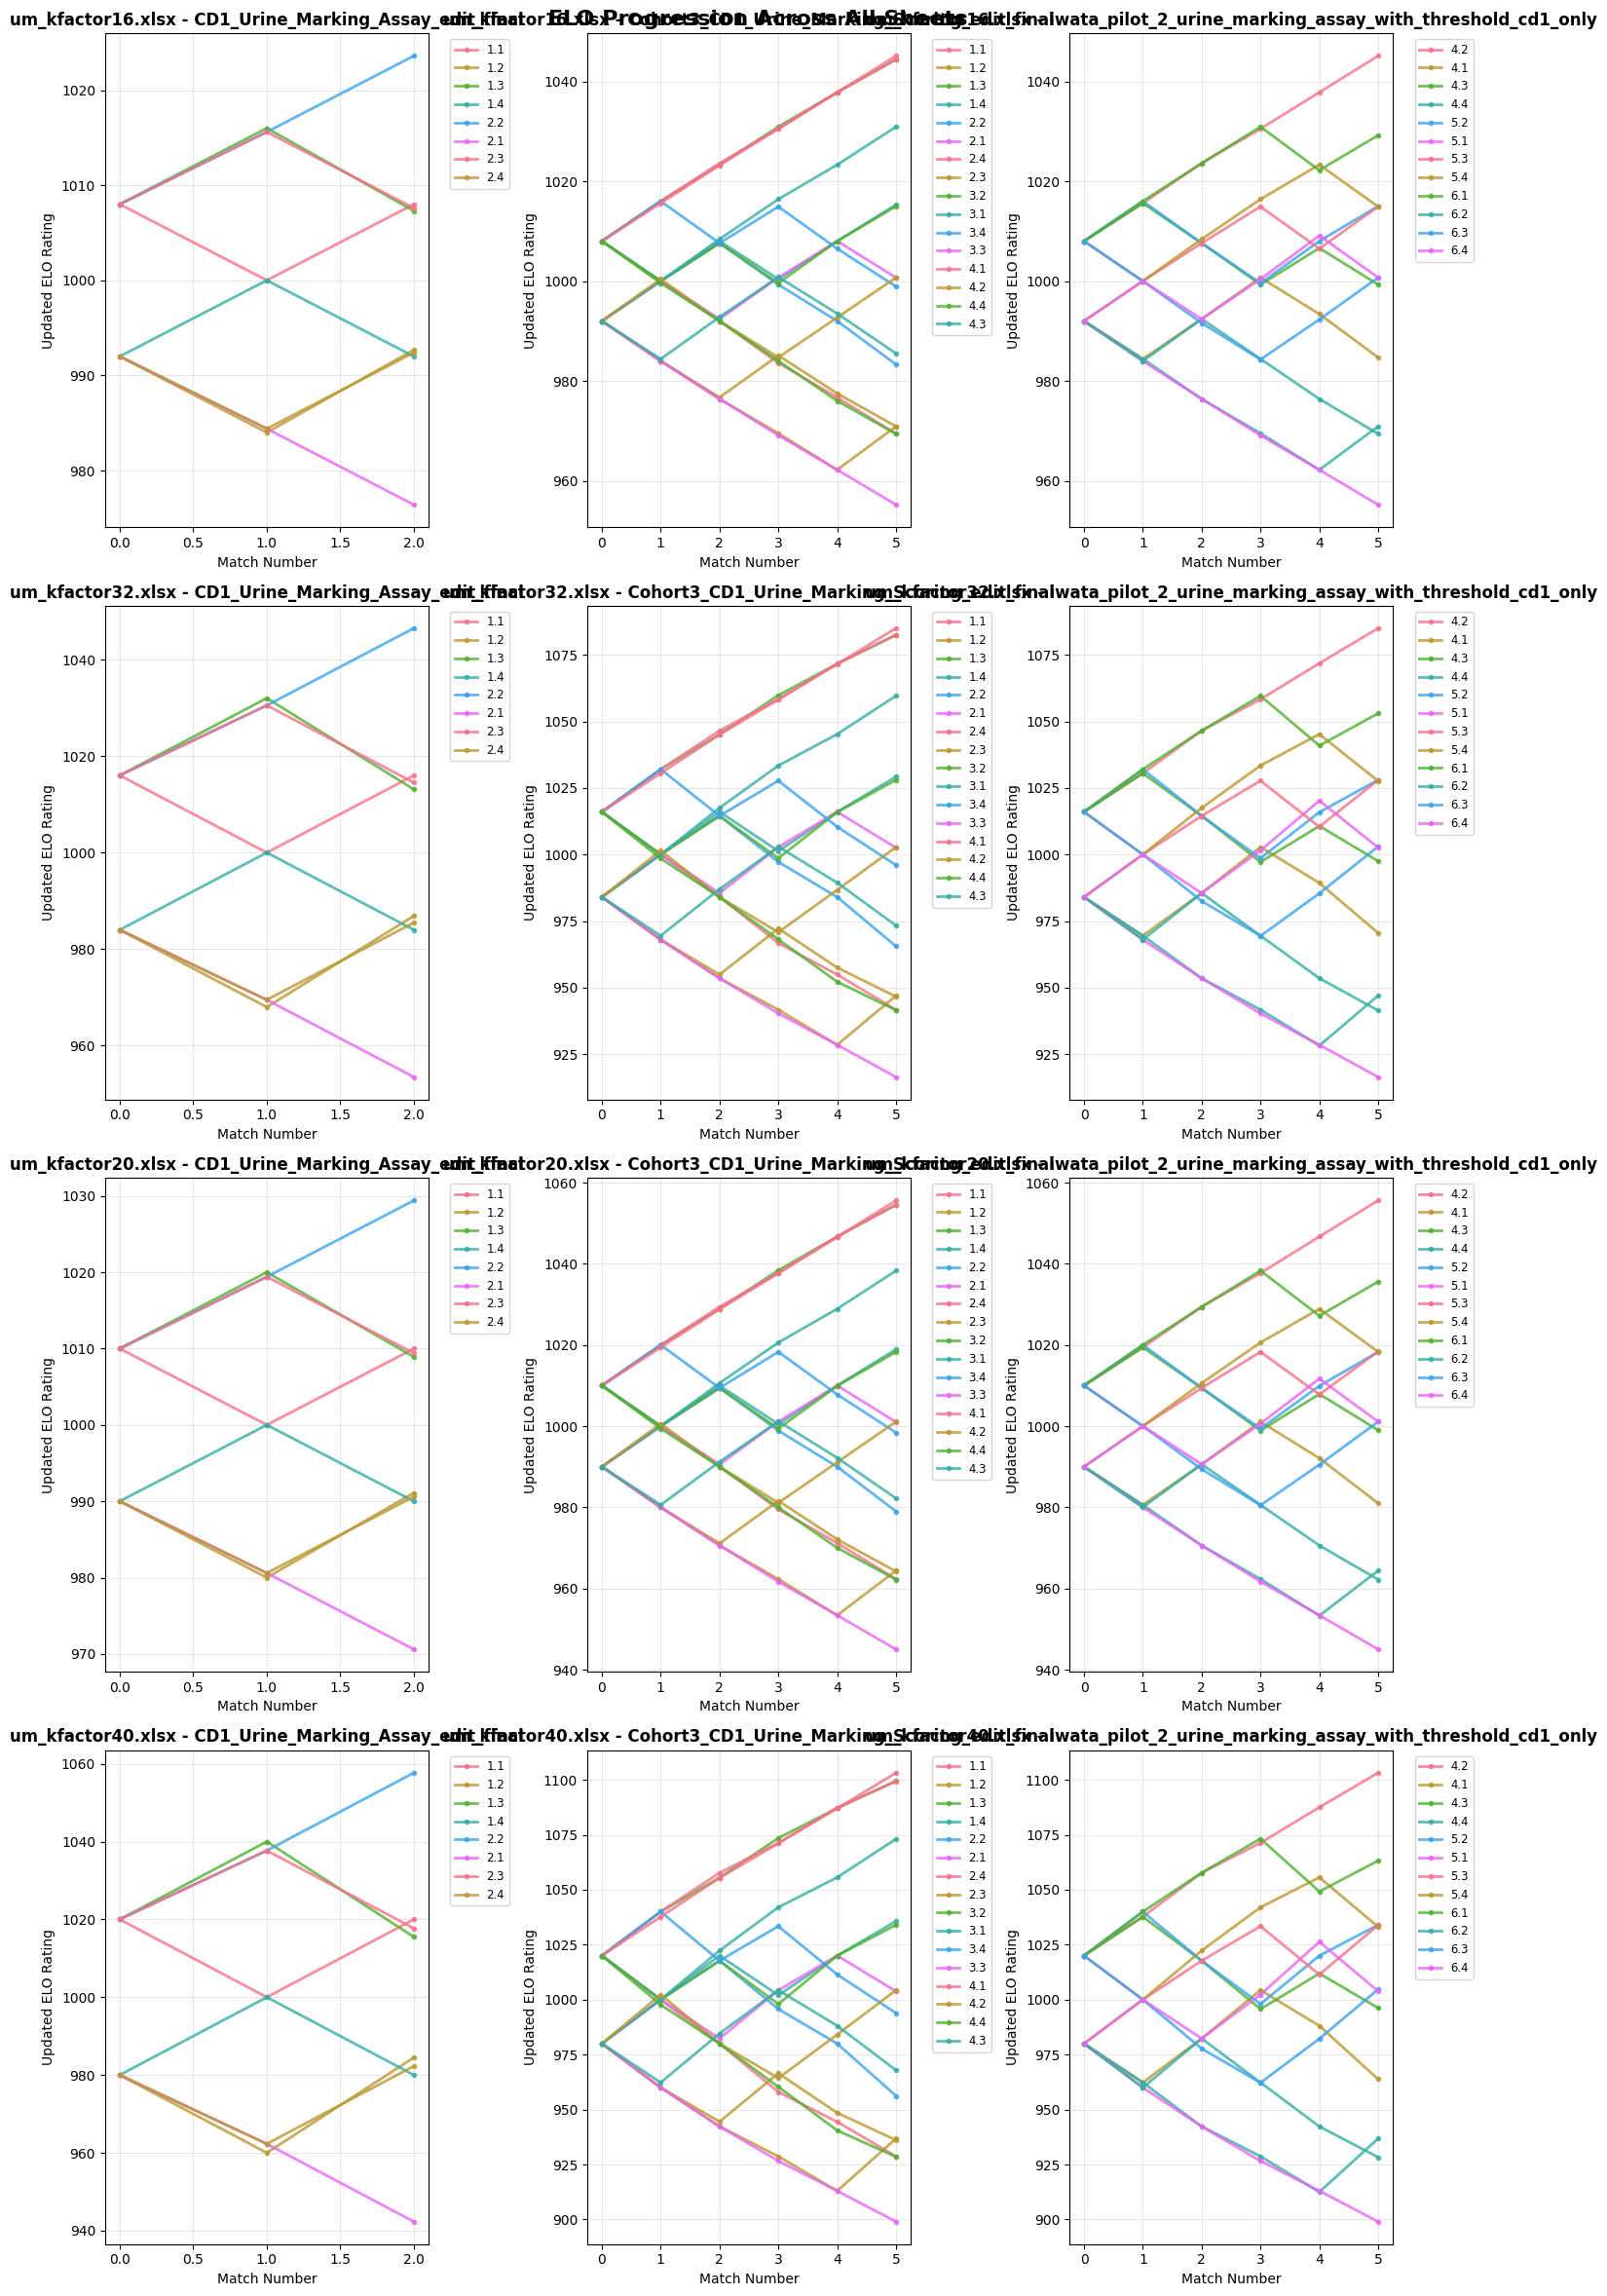

In [42]:
file_paths = [r'C:\Users\megha\Documents\GitHub\social_competiton_elo_rating\jupyter_notebooks\data\nina\um_kfactor16.xlsx',
              r'C:\Users\megha\Documents\GitHub\social_competiton_elo_rating\jupyter_notebooks\data\nina\um_kfactor32.xlsx',
              r'C:\Users\megha\Documents\GitHub\social_competiton_elo_rating\jupyter_notebooks\data\nina\um_kfactor20.xlsx',
              r'C:\Users\megha\Documents\GitHub\social_competiton_elo_rating\jupyter_notebooks\data\nina\um_kfactor40.xlsx']
plot_elo_progression_subplots(file_paths)

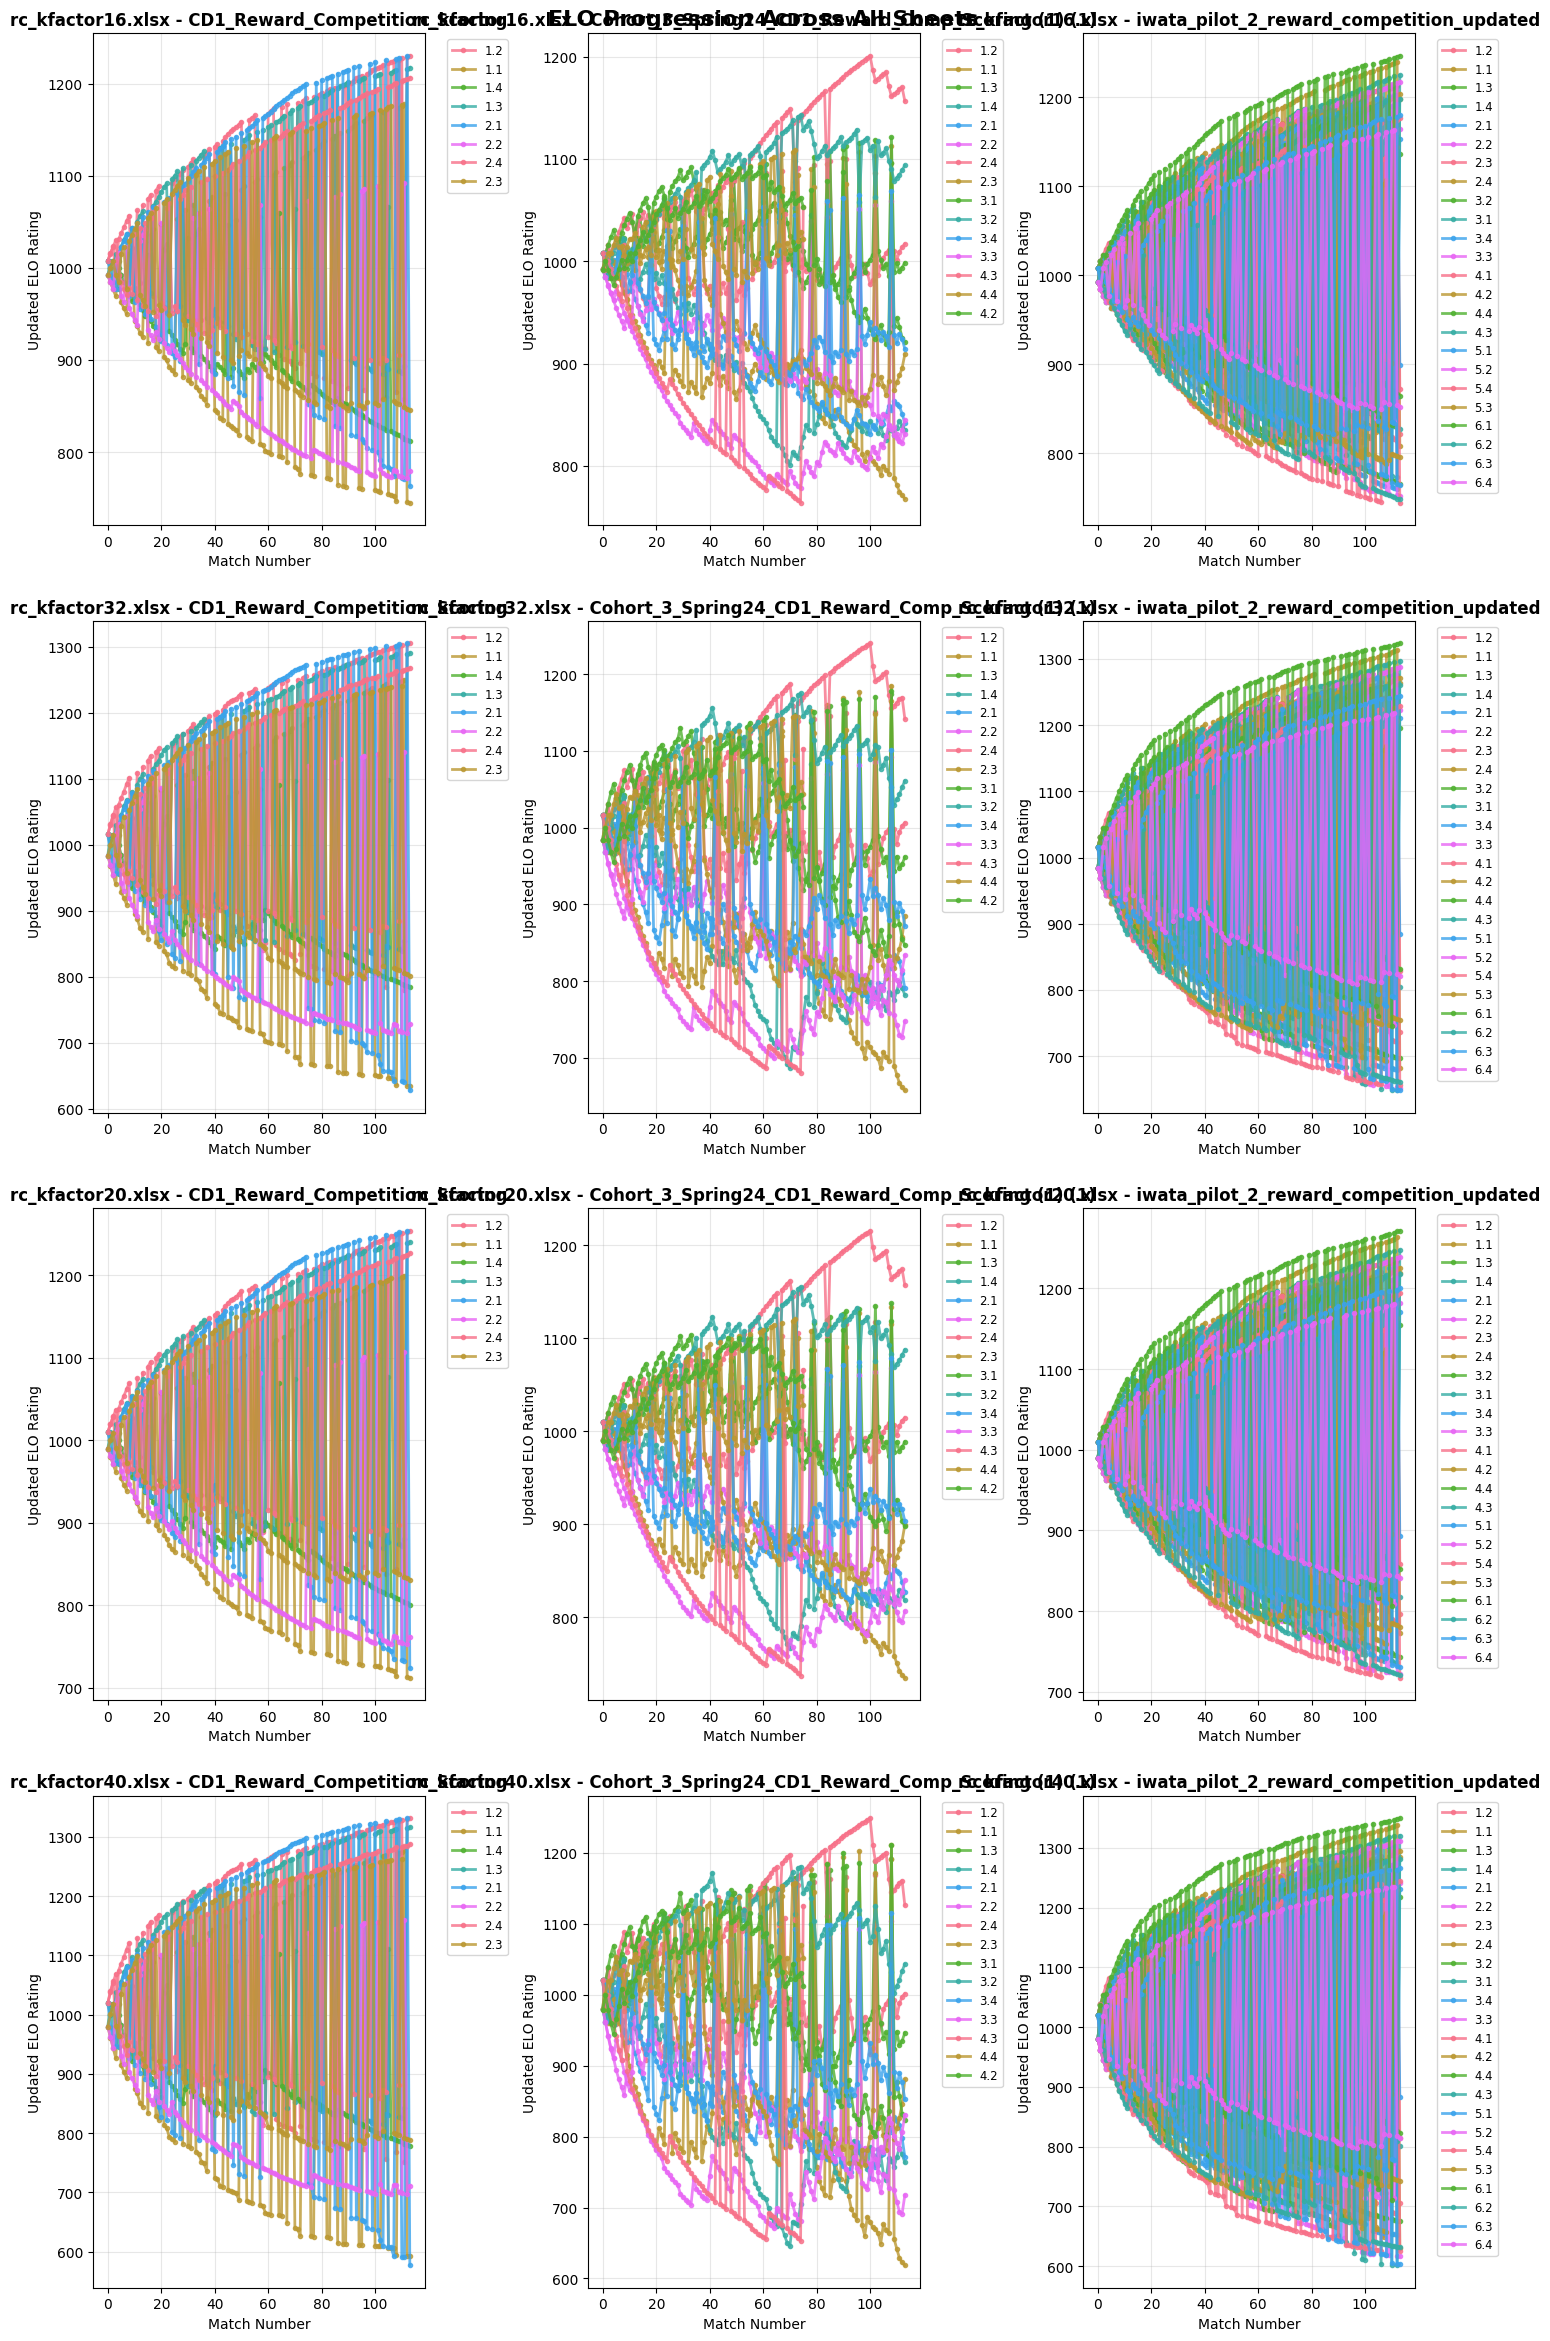

In [43]:
file_paths = [r'C:\Users\megha\Documents\GitHub\social_competiton_elo_rating\jupyter_notebooks\data\nina\rc_kfactor16.xlsx',
              r'C:\Users\megha\Documents\GitHub\social_competiton_elo_rating\jupyter_notebooks\data\nina\rc_kfactor32.xlsx',
              r'C:\Users\megha\Documents\GitHub\social_competiton_elo_rating\jupyter_notebooks\data\nina\rc_kfactor20.xlsx',
              r'C:\Users\megha\Documents\GitHub\social_competiton_elo_rating\jupyter_notebooks\data\nina\rc_kfactor40.xlsx']
plot_elo_progression_subplots(file_paths)